# AI Destekli Müşteri Analitiği Projesi
## Customer Segmentation + Churn Prediction + Behavioral Analysis

Bu notebook tek bir uçtan uca akıştır: veri ön işleme → öznitelik mühendisliği →
müşteri segmentasyonu → churn tahmini → davranışsal kural çıkarımı → müşteri değeri →
özet dashboard → model açıklanabilirliği (SHAP) → bonus birliktelik analizi (Apriori).

**Akış**
1. Problem tanımı
2. Veri yükleme ve ön işleme
3. Öznitelik mühendisliği (RFM)
4. Müşteri segmentasyonu (K-Means)
5. Churn tahmini (Logistic Regression + Random Forest)
6. Davranışsal kural çıkarımı
7. Müşteri değeri analizi
8. Özet dashboard
9. Model açıklanabilirliği (Feature importance + SHAP + Confusion Matrix)
10. Bonus: Sentetik veri ile Apriori birliktelik analizi
11. Sonuç ve öneriler


## 1. Problem Tanımı

Müşteri kaybını (churn) azaltmak, yüksek değerli müşterileri belirlemek ve kullanıcı
davranışlarını anlamak amacıyla veri analizi ve makine öğrenmesi teknikleri kullanılmıştır.
Çalışma üç soruya yanıt arar: *(i)* Müşteriler hangi davranışsal gruplara ayrılır?
*(ii)* Hangi müşteriler ayrılma riski taşır? *(iii)* Hangi davranış örüntüleri churn ve
sadakatle ilişkilidir?

## Kurulum ve Kütüphaneler

In [22]:
pip install shap mlxtend -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [23]:
# Colab'da SHAP ve mlxtend kurulu değilse:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, recall_score,
                             precision_score, f1_score, accuracy_score)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42
CHURN_PAL = {0: "#4C9F70", 1: "#D1495B"}
print("Hazır.")

Hazır.


## 2. Veri Yükleme ve Ön İşleme

Adımlar: PII kolonlarını çıkar → mantıken imkânsız değerleri (negatif satın alma, %100'ü
aşan oranlar, aşırı yaş) düzelt → eksik değerleri doldur → çok boş kolonları (eşik %40) sil.

In [24]:
DATA_PATH = "customers.csv"   # Colab'da dosyayı notebook ile aynı dizine koy
df = pd.read_csv(DATA_PATH)
print("Ham veri:", df.shape)

TARGET = "Churned"
ID_COLS = ["name", "email", "phone"]
CATEGORICAL = ["Gender", "Country", "City", "Signup_Quarter"]

# 2.1 PII kolonlarını çıkar
df = df.drop(columns=ID_COLS)
print("PII çıkarıldı ->", df.shape)

Ham veri: (50000, 28)
PII çıkarıldı -> (50000, 25)


In [25]:
# 2.2 Veri kalitesi düzeltmeleri (hatalı değerleri NaN/sınıra çek)
before_na = df.isna().sum().sum()

# Yaş makul aralık dışı -> NaN
df.loc[(df["Age"] < 13) | (df["Age"] > 100), "Age"] = np.nan
# Negatif satın alma imkansız -> NaN
df.loc[df["Total_Purchases"] < 0, "Total_Purchases"] = np.nan
# Yüzde kolonlarını [0, 100] aralığına kırp
rate_cols = ["Cart_Abandonment_Rate", "Returns_Rate",
             "Discount_Usage_Rate", "Email_Open_Rate"]
for c in rate_cols:
    df[c] = df[c].clip(lower=0, upper=100)

print(f"Düzeltme sonrası eklenen NaN: {df.isna().sum().sum() - before_na}")

Düzeltme sonrası eklenen NaN: 90


In [26]:
# 2.3 Çok boş kolonları sil (eşik %40) — bu veride hiçbiri eşiği aşmıyor
THRESH = 0.40
high_missing = df.columns[df.isna().mean() > THRESH].tolist()
print("Silinecek kolon (>%40 boş):", high_missing if high_missing else "yok")
df = df.drop(columns=high_missing)

# 2.4 Eksik değer doldurma: sayısal -> median, kategorik -> mode
num_cols = df.select_dtypes(include=[np.number]).columns.drop(TARGET)
cat_cols = [c for c in CATEGORICAL if c in df.columns]

for c in num_cols:
    df[c] = df[c].fillna(df[c].median())
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

print("Kalan eksik değer:", df.isna().sum().sum())

Silinecek kolon (>%40 boş): yok
Kalan eksik değer: 0


## 3. Öznitelik Mühendisliği — RFM

RFM, müşteriyi üç eksende skorlar: **Recency** (son alışveriştan bu yana geçen gün — düşük
iyi), **Frequency** (etkileşim/işlem sıklığı), **Monetary** (yaşam boyu değer). Her ekseni
4 dilime böler ve 3–12 arası bir toplam skor üretir.

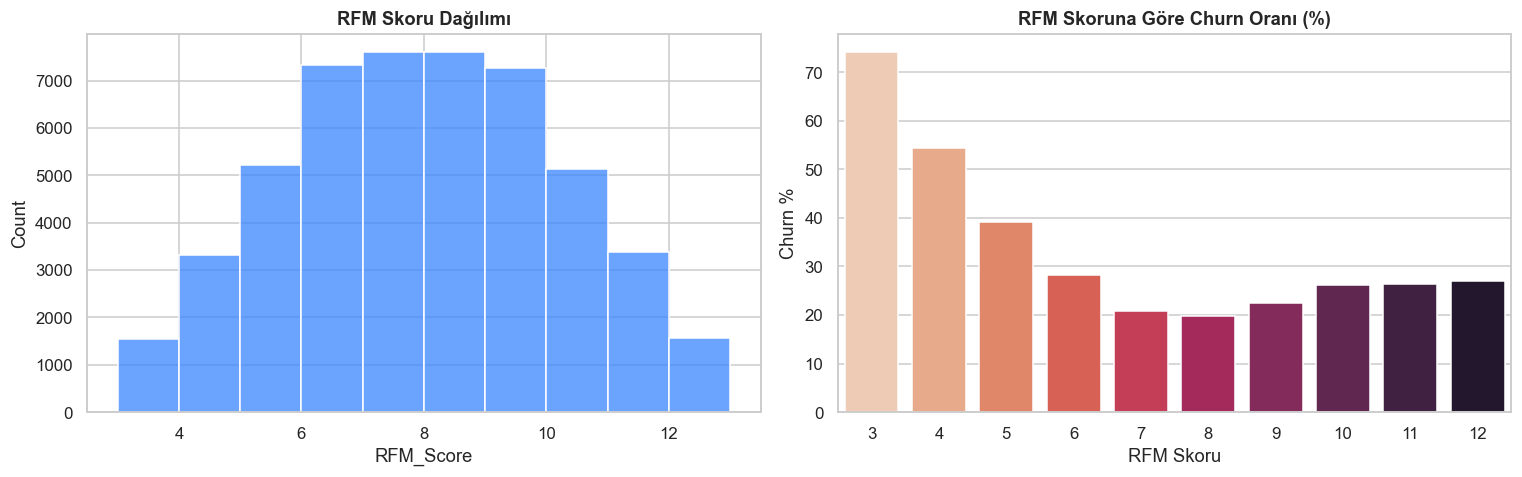

In [27]:
df["R_Score"] = pd.qcut(df["Days_Since_Last_Purchase"].rank(method="first"),
                        4, labels=[4, 3, 2, 1]).astype(int)   # düşük recency = iyi
df["F_Score"] = pd.qcut(df["Login_Frequency"].rank(method="first"),
                        4, labels=[1, 2, 3, 4]).astype(int)
df["M_Score"] = pd.qcut(df["Lifetime_Value"].rank(method="first"),
                        4, labels=[1, 2, 3, 4]).astype(int)
df["RFM_Score"] = df[["R_Score", "F_Score", "M_Score"]].sum(axis=1)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(df["RFM_Score"], bins=range(3, 14), color="#3A86FF", ax=ax[0])
ax[0].set_title("RFM Skoru Dağılımı")
churn_by_rfm = df.groupby("RFM_Score")[TARGET].mean() * 100
sns.barplot(x=churn_by_rfm.index, y=churn_by_rfm.values, palette="rocket_r", ax=ax[1])
ax[1].set_title("RFM Skoruna Göre Churn Oranı (%)")
ax[1].set_xlabel("RFM Skoru"); ax[1].set_ylabel("Churn %")
plt.tight_layout(); plt.show()

## 4. Müşteri Segmentasyonu (K-Means)

Davranışsal eksenlerde (LTV, toplam satın alma, login sıklığı, indirim kullanımı) müşterileri
gruplarız. Önce uygun k'yı elbow ve silhouette ile seçer, sonra segmentleri profilleriz.

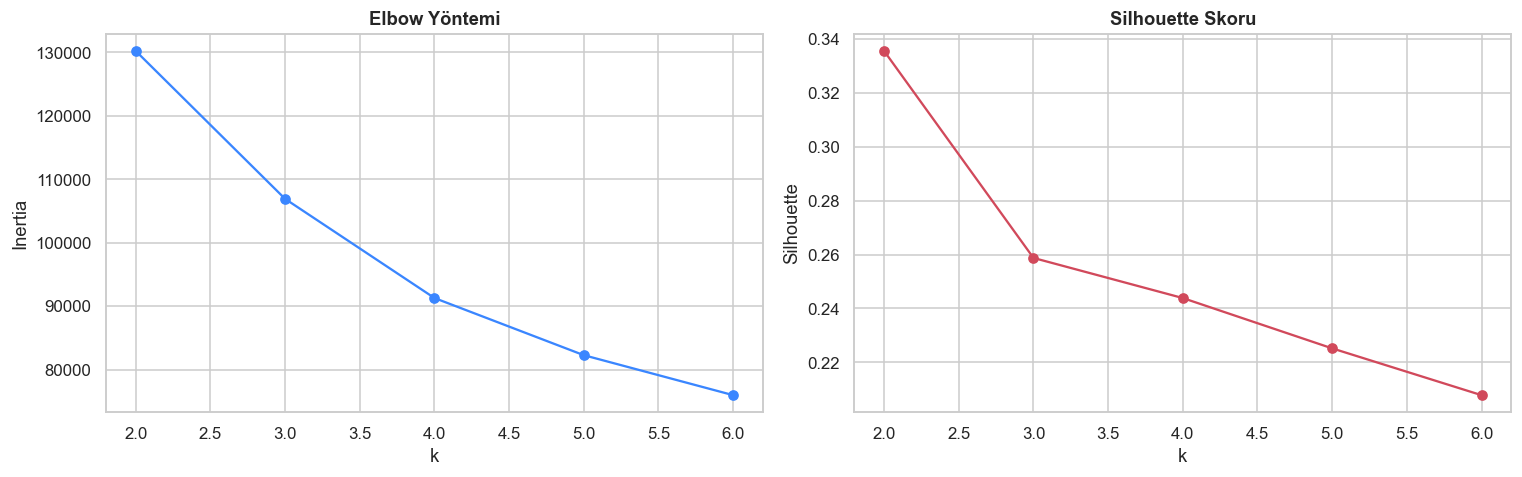

In [28]:
seg_features = ["Lifetime_Value", "Total_Purchases",
                "Login_Frequency", "Discount_Usage_Rate"]
X_seg = StandardScaler().fit_transform(df[seg_features])

inertias, sils = [], []
K_RANGE = range(2, 7)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_seg)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_seg, km.labels_, sample_size=5000,
                                 random_state=RANDOM_STATE))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(list(K_RANGE), inertias, "o-", color="#3A86FF")
ax[0].set_title("Elbow Yöntemi"); ax[0].set_xlabel("k"); ax[0].set_ylabel("Inertia")
ax[1].plot(list(K_RANGE), sils, "o-", color="#D1495B")
ax[1].set_title("Silhouette Skoru"); ax[1].set_xlabel("k"); ax[1].set_ylabel("Silhouette")
plt.tight_layout(); plt.show()

In [29]:
# Seçilen k ile son model
K = 4
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
df["Segment"] = kmeans.fit_predict(X_seg)

# Segment profili
profile = df.groupby("Segment")[seg_features].mean().round(1)
profile["Churn_Rate_%"] = (df.groupby("Segment")[TARGET].mean() * 100).round(1)
profile["Müşteri_Sayısı"] = df["Segment"].value_counts().sort_index()
profile

,Lifetime_Value,Total_Purchases,Login_Frequency,Discount_Usage_Rate,Churn_Rate_%,Müşteri_Sayısı
Segment,,,,,,
0,2877.4,23.3,21.8,45.5,26.2,7478
1,1195.7,11.6,9.6,67.3,23.5,11665
2,801.8,7.8,5.3,32.3,38.6,16252
3,1611.5,15.0,15.1,30.2,23.9,14605


Segment isimleri (profile göre):
  Segment 0 -> High Value
  Segment 1 -> Discount Lovers
  Segment 2 -> Passive / At Risk
  Segment 3 -> Standart


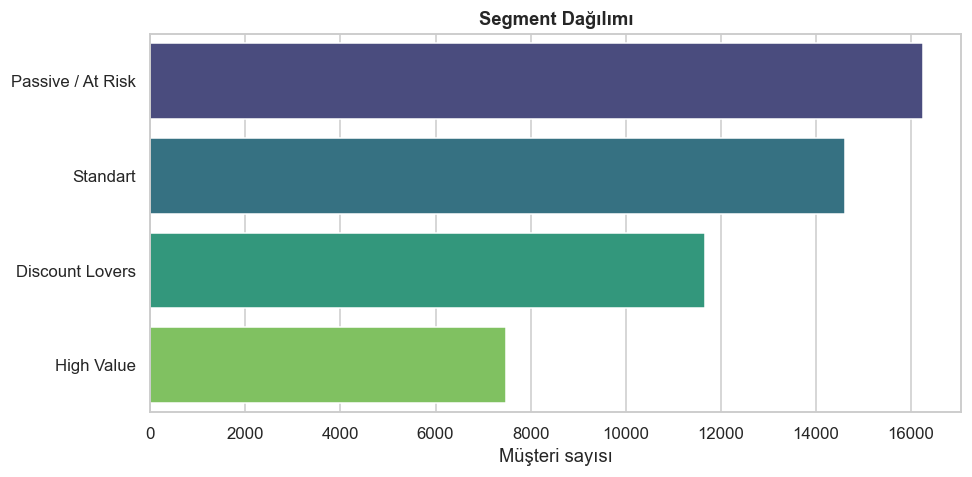

In [30]:
# Profillere göre iş anlamı taşıyan otomatik isimlendirme
z = (profile[seg_features] - profile[seg_features].mean()) / profile[seg_features].std()
names = {}
for seg in profile.index:
    ltv, freq, disc = z.loc[seg, "Lifetime_Value"], z.loc[seg, "Login_Frequency"], z.loc[seg, "Discount_Usage_Rate"]
    if ltv > 0.5:
        names[seg] = "High Value"
    elif disc > 0.5:
        names[seg] = "Discount Lovers"
    elif freq < -0.3:
        names[seg] = "Passive / At Risk"
    else:
        names[seg] = "Standart"
df["Segment_Adi"] = df["Segment"].map(names)
print("Segment isimleri (profile göre):")
for s, n in names.items():
    print(f"  Segment {s} -> {n}")

plt.figure(figsize=(9, 4.5))
order = df["Segment_Adi"].value_counts().index
sns.countplot(y="Segment_Adi", data=df, order=order, palette="viridis")
plt.title("Segment Dağılımı"); plt.xlabel("Müşteri sayısı"); plt.ylabel("")
plt.tight_layout(); plt.show()

## 5. Churn Tahmini (Supervised)

Hedef `Churned`. Önce Logistic Regression (baseline), sonra Random Forest (asıl model).
Sınıf dengesizliği için `class_weight="balanced"`, davranışsal + kodlanmış kategorik
öznitelikler kullanılır.

> **Sızıntı (leakage) notu:** `Days_Since_Last_Purchase` churn etiketinin tanımına bağlı
> olarak hedefi sızdırabilir. Aşırı yüksek bir önem gösterirse etiketin nasıl üretildiği
> doğrulanmalıdır.

In [31]:
# Modelleme matrisi: sayısal + one-hot kategorik (City hariç -> 40 sınıf çok seyrek)
model_df = df.drop(columns=["Segment", "Segment_Adi", "City"])
model_df = pd.get_dummies(model_df, columns=["Gender", "Country", "Signup_Quarter"],
                          drop_first=True)

X = model_df.drop(columns=TARGET)
y = model_df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print("Eğitim:", X_train.shape, "| Test:", X_test.shape)

# Logistic Regression ölçekli veri ister
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

Eğitim: (37500, 36) | Test: (12500, 36)


In [32]:
def evaluate(name, y_true, y_pred, y_proba):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_proba),
    }

# 5.1 Logistic Regression (baseline)
logreg = LogisticRegression(max_iter=1000, class_weight="balanced",
                            random_state=RANDOM_STATE)
logreg.fit(X_train_s, y_train)
lr_pred = logreg.predict(X_test_s)
lr_proba = logreg.predict_proba(X_test_s)[:, 1]

# 5.2 Random Forest (asıl model)
rf = RandomForestClassifier(n_estimators=150, class_weight="balanced",
                            max_depth=12, n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

results = pd.DataFrame([
    evaluate("Logistic Regression", y_test, lr_pred, lr_proba),
    evaluate("Random Forest", y_test, rf_pred, rf_proba),
]).set_index("Model").round(3)
results

,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Logistic Regression,0.716,0.506,0.731,0.598,0.793
Random Forest,0.910,0.871,0.808,0.838,0.926


Random Forest — sınıflandırma raporu:

              precision    recall  f1-score   support

       Kalan       0.92      0.95      0.94      8888
     Ayrılan       0.87      0.81      0.84      3612

    accuracy                           0.91     12500
   macro avg       0.90      0.88      0.89     12500
weighted avg       0.91      0.91      0.91     12500



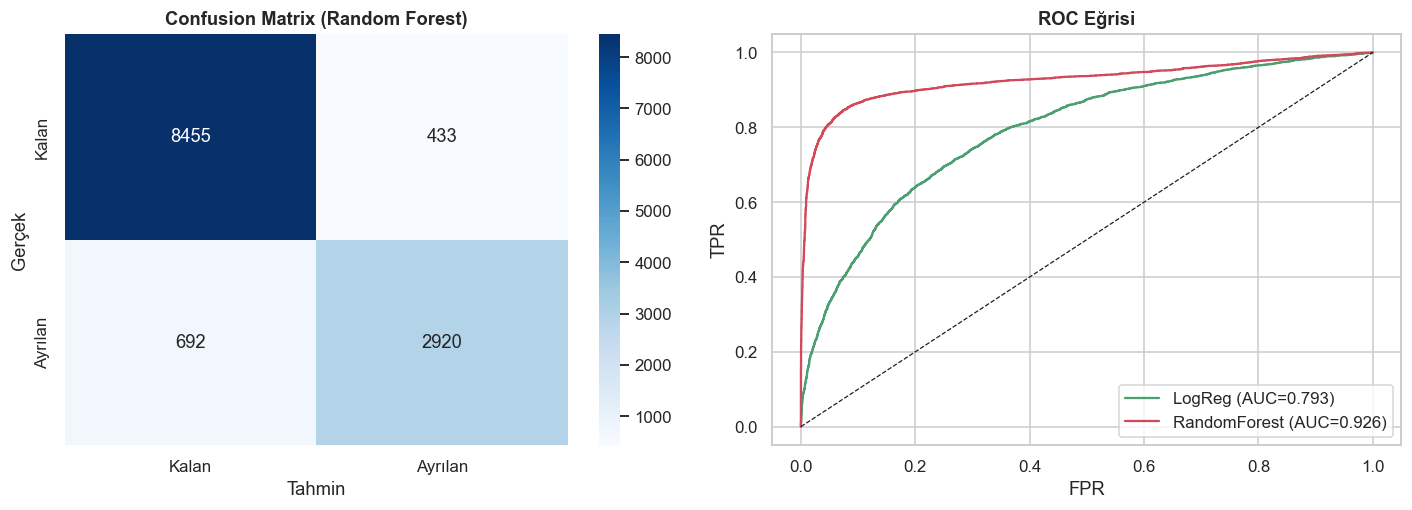

In [33]:
# Random Forest detaylı rapor + confusion matrix
print("Random Forest — sınıflandırma raporu:\n")
print(classification_report(y_test, rf_pred, target_names=["Kalan", "Ayrılan"]))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[0],
            xticklabels=["Kalan", "Ayrılan"], yticklabels=["Kalan", "Ayrılan"])
ax[0].set_title("Confusion Matrix (Random Forest)")
ax[0].set_xlabel("Tahmin"); ax[0].set_ylabel("Gerçek")

for name, proba, c in [("LogReg", lr_proba, "#4C9F70"), ("RandomForest", rf_proba, "#D1495B")]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax[1].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})", color=c)
ax[1].plot([0, 1], [0, 1], "k--", lw=0.8)
ax[1].set_title("ROC Eğrisi"); ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR")
ax[1].legend()
plt.tight_layout(); plt.show()

## 6. Davranışsal Kural Çıkarımı (Association-like Behavioral Rules)

Ürün bazlı işlem verisi bulunmadığı için klasik birliktelik analizi yerine, müşteri
davranışları üzerinden veriyle desteklenen ilişki kuralları çıkarılmıştır. Önce korelasyon,
sonra eşik tabanlı kuralların gerçek oranları hesaplanır.

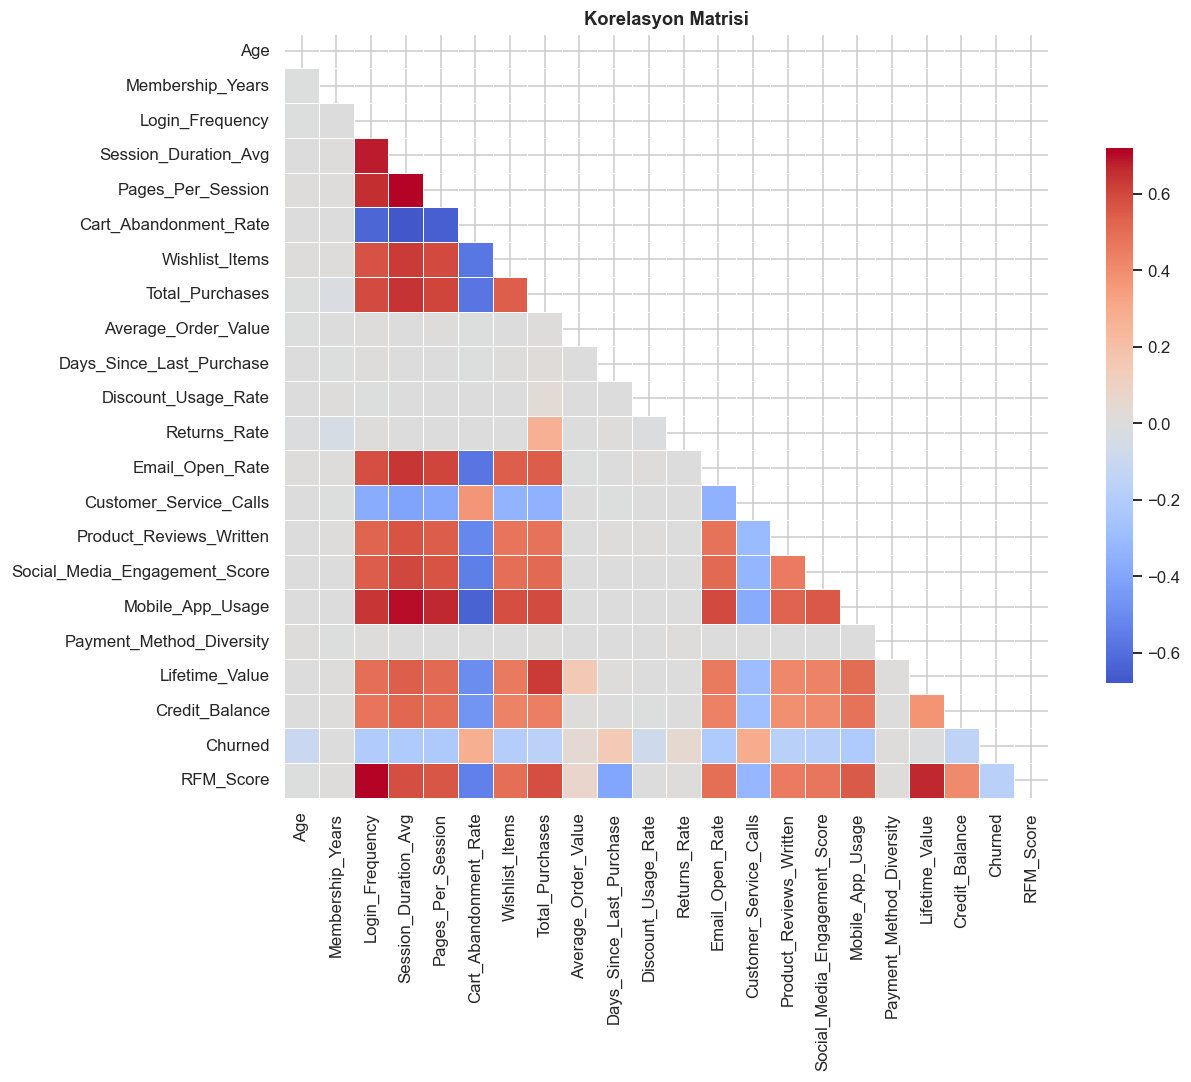

In [34]:
num_for_corr = df.select_dtypes(include=[np.number]).drop(
    columns=["R_Score", "F_Score", "M_Score", "Segment"], errors="ignore")
plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(num_for_corr.corr(), dtype=bool))
sns.heatmap(num_for_corr.corr(), mask=mask, cmap="coolwarm", center=0,
            square=True, linewidths=0.4, cbar_kws={"shrink": 0.7})
plt.title("Korelasyon Matrisi"); plt.tight_layout(); plt.show()

In [35]:
# Eşik tabanlı kuralları veriyle doğrula
overall_churn = df[TARGET].mean() * 100
rules = []

# Kural 1: yüksek sepet terki -> churn
high_cart = df["Cart_Abandonment_Rate"] > 60
rules.append(["Cart_Abandonment_Rate > 60 ise churn",
              f"{df.loc[high_cart, TARGET].mean()*100:.1f}%",
              f"{overall_churn:.1f}%"])

# Kural 2: düşük login -> churn (alt çeyrek)
low_login = df["Login_Frequency"] <= df["Login_Frequency"].quantile(0.25)
rules.append(["Login_Frequency düşük (alt %25) ise churn",
              f"{df.loc[low_login, TARGET].mean()*100:.1f}%",
              f"{overall_churn:.1f}%"])

# Kural 3: yüksek indirim kullanımı -> daha çok satın alma
high_disc = df["Discount_Usage_Rate"] > df["Discount_Usage_Rate"].median()
rules.append(["Discount_Usage yüksek ise ort. Total_Purchases",
              f"{df.loc[high_disc, 'Total_Purchases'].mean():.1f}",
              f"{df.loc[~high_disc, 'Total_Purchases'].mean():.1f} (düşük grup)"])

# Kural 4: yüksek sepet terki -> daha az satın alma
rules.append(["Cart_Abandonment > 60 ise ort. Total_Purchases",
              f"{df.loc[high_cart, 'Total_Purchases'].mean():.1f}",
              f"{df.loc[~high_cart, 'Total_Purchases'].mean():.1f} (düşük terk)"])

rules_df = pd.DataFrame(rules, columns=["Kural", "Koşullu Değer", "Karşılaştırma"])
rules_df

,Kural,Koşullu Değer,Karşılaştırma
0,Cart_Abandonment_Rate > 60 ise churn,40.4%,28.9%
1,Login_Frequency düşük (alt %25) ise churn,43.5%,28.9%
2,Discount_Usage yüksek ise ort. Total_Purchases,13.3,13.0 (düşük grup)
3,Cart_Abandonment > 60 ise ort. Total_Purchases,9.6,16.0 (düşük terk)


## 7. Müşteri Değeri Analizi

In [36]:
# En değerli 10 müşteri (PII yok; indeks + segment ile)
top_customers = (df.sort_values("Lifetime_Value", ascending=False)
                 .head(10)[["Lifetime_Value", "Total_Purchases",
                            "RFM_Score", "Segment_Adi", TARGET]])
print("En yüksek yaşam boyu değere sahip 10 müşteri:")
display(top_customers)

# Segment bazında toplam ve ortalama değer
seg_value = df.groupby("Segment_Adi").agg(
    Toplam_LTV=("Lifetime_Value", "sum"),
    Ortalama_LTV=("Lifetime_Value", "mean"),
    Musteri=("Lifetime_Value", "count"),
    Churn_Orani=(TARGET, "mean")).round(1).sort_values("Toplam_LTV", ascending=False)
seg_value["Churn_Orani"] = (seg_value["Churn_Orani"] * 100).round(1)
print("\nEn karlı segment (toplam LTV'ye göre):")
seg_value

En yüksek yaşam boyu değere sahip 10 müşteri:


,Lifetime_Value,Total_Purchases,RFM_Score,Segment_Adi,Churned
43141,8987.24,28.0,8,High Value,1
40771,8243.53,24.0,9,High Value,1
9361,8023.20,28.0,9,High Value,0
37041,7990.07,33.0,9,High Value,0
31921,7631.01,23.0,10,High Value,1
26887,7533.68,20.0,11,High Value,0
48071,7507.81,26.0,12,High Value,1
28543,7488.19,20.0,10,High Value,0
23780,7429.18,23.0,12,High Value,0
28949,7324.28,25.0,8,High Value,0



En karlı segment (toplam LTV'ye göre):


,Toplam_LTV,Ortalama_LTV,Musteri,Churn_Orani
Segment_Adi,,,,
Standart,23536308.2,1611.5,14605,20.0
High Value,21516990.6,2877.4,7478,30.0
Discount Lovers,13947846.8,1195.7,11665,20.0
Passive / At Risk,13030169.0,801.8,16252,40.0


## 8. Özet Dashboard

Power BI / Tableau yerine Python ile dört temel görünüm: segment dağılımı, segment bazında
churn, segment değeri ve davranış örüntüsü.

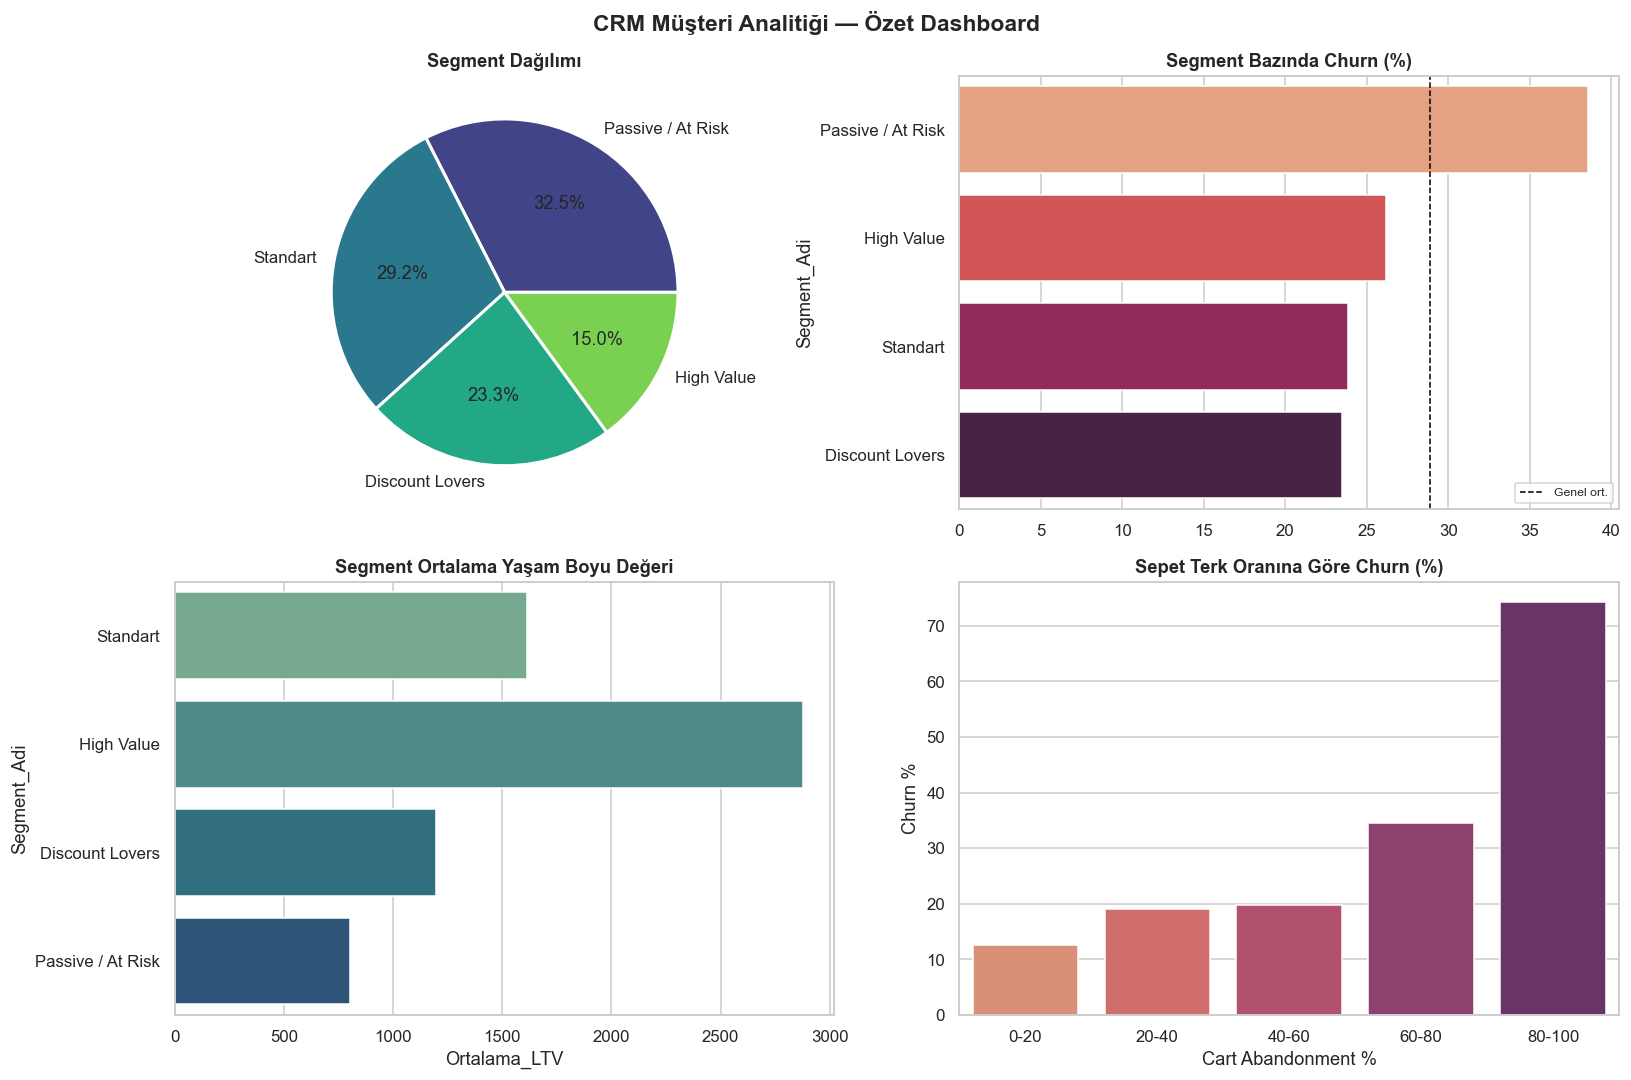

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# (1) Segment dağılımı
seg_counts = df["Segment_Adi"].value_counts()
axes[0, 0].pie(seg_counts, labels=seg_counts.index, autopct="%1.1f%%",
               colors=sns.color_palette("viridis", len(seg_counts)),
               wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[0, 0].set_title("Segment Dağılımı")

# (2) Segment bazında churn
ch = (df.groupby("Segment_Adi")[TARGET].mean()*100).sort_values(ascending=False)
sns.barplot(x=ch.values, y=ch.index, palette="rocket_r", ax=axes[0, 1])
axes[0, 1].axvline(overall_churn, color="black", ls="--", lw=1, label="Genel ort.")
axes[0, 1].set_title("Segment Bazında Churn (%)"); axes[0, 1].legend(fontsize=8)

# (3) Segment ortalama LTV
sns.barplot(x=seg_value["Ortalama_LTV"], y=seg_value.index,
            palette="crest", ax=axes[1, 0])
axes[1, 0].set_title("Segment Ortalama Yaşam Boyu Değeri")

# (4) Sepet terk oranı kovaları vs churn
df["_cab_bin"] = pd.cut(df["Cart_Abandonment_Rate"],
                        bins=[0, 20, 40, 60, 80, 100],
                        labels=["0-20", "20-40", "40-60", "60-80", "80-100"])
cab = (df.groupby("_cab_bin")[TARGET].mean()*100)
sns.barplot(x=cab.index, y=cab.values, palette="flare", ax=axes[1, 1])
axes[1, 1].set_title("Sepet Terk Oranına Göre Churn (%)")
axes[1, 1].set_xlabel("Cart Abandonment %"); axes[1, 1].set_ylabel("Churn %")
df.drop(columns="_cab_bin", inplace=True)

plt.suptitle("CRM Müşteri Analitiği — Özet Dashboard", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

## 9. Model Açıklanabilirliği — Feature Importance + SHAP

Random Forest'ın hangi özniteliklere dayandığını iki yöntemle inceleriz: yerleşik
feature importance ve SHAP değerleri (her tahminin nasıl oluştuğunu gösterir).

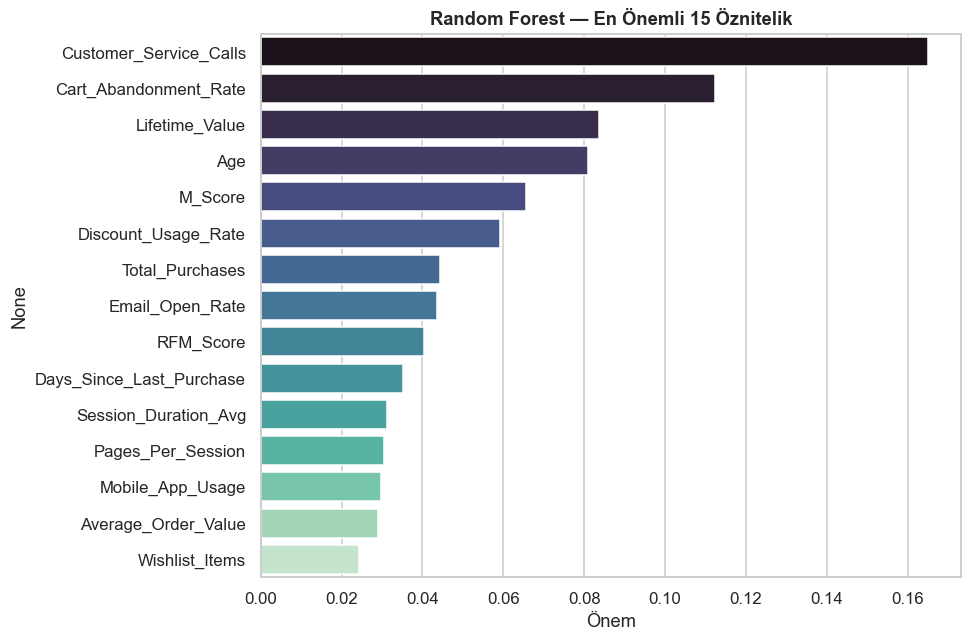

In [38]:
# 9.1 Yerleşik feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, palette="mako")
plt.title("Random Forest — En Önemli 15 Öznitelik")
plt.xlabel("Önem"); plt.tight_layout(); plt.show()

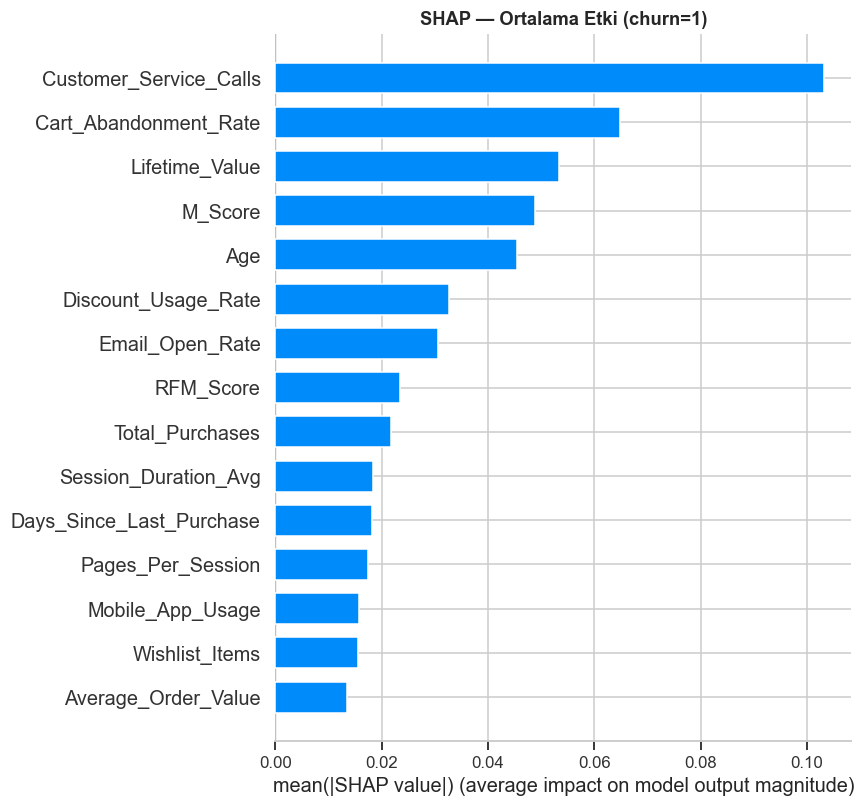

In [39]:
# 9.2 SHAP (TreeExplainer) — hız için örneklem
import shap
sample = X_test.sample(min(400, len(X_test)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(sample, check_additivity=False)

# İkili sınıflandırmada pozitif sınıf (churn=1) için SHAP değerleri
sv = shap_values[1] if isinstance(shap_values, list) else shap_values[..., 1]
shap.summary_plot(sv, sample, plot_type="bar", show=False, max_display=15)
plt.title("SHAP — Ortalama Etki (churn=1)")
plt.tight_layout(); plt.show()

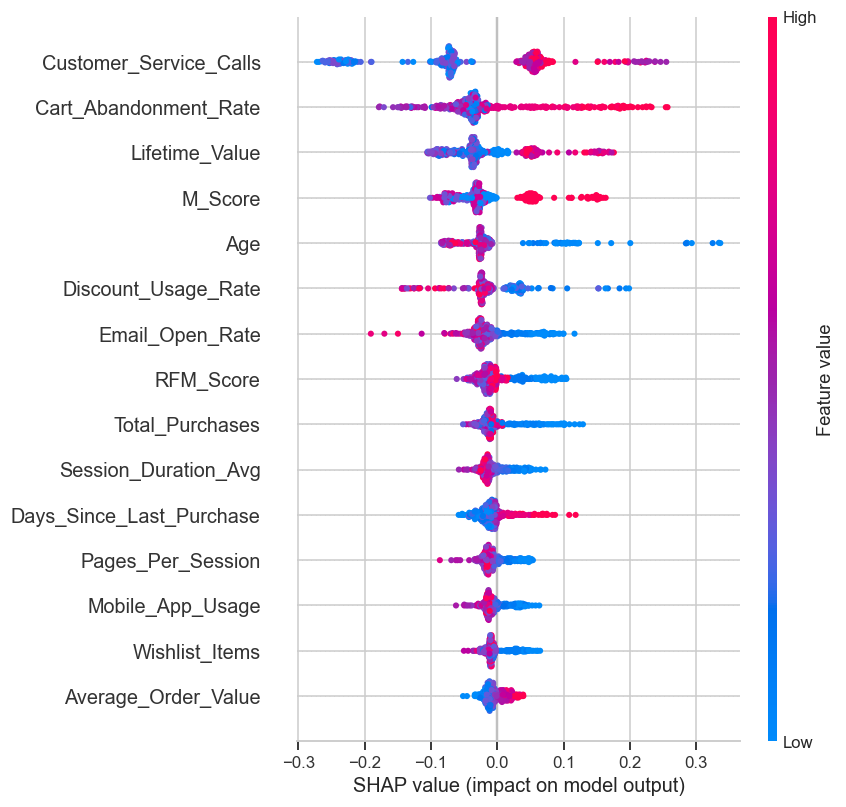

In [40]:
# SHAP beeswarm — yön ve büyüklük birlikte
shap.summary_plot(sv, sample, show=False, max_display=15)
plt.tight_layout(); plt.show()

## 10. Bonus — Sentetik Veri ile Birliktelik Analizi (Apriori)

Ürün bazlı veri olmadığı için, segment ve davranış profillerine dayalı **sentetik sepet
verisi** üretip Apriori ile birliktelik kuralları çıkarılmıştır. Bu, klasik market-basket
analizinin nasıl uygulanacağını gösterir.

> Not: Bu bölüm sentetik veriyle çalışır; gerçek satın alma örüntüsü değil, yöntem gösterimidir.

In [41]:
from mlxtend.frequent_patterns import apriori, association_rules

rng = np.random.default_rng(RANDOM_STATE)
products = ["Elektronik", "Giyim", "Kitap", "Kozmetik", "Ev", "Spor", "Oyuncak", "Gida"]

# Segmente göre eğilimli sentetik sepetler
seg_pref = {
    "High Value":        [0.6, 0.4, 0.3, 0.3, 0.5, 0.4, 0.2, 0.3],
    "Discount Lovers":   [0.3, 0.7, 0.2, 0.6, 0.3, 0.3, 0.4, 0.5],
    "Passive / At Risk": [0.2, 0.2, 0.5, 0.2, 0.2, 0.1, 0.1, 0.4],
    "Standart":          [0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.3, 0.4],
}
baskets = []
seg_sample = df["Segment_Adi"].sample(5000, random_state=RANDOM_STATE)
for seg in seg_sample:
    probs = seg_pref.get(seg, seg_pref["Standart"])
    basket = [p for p, pr in zip(products, probs) if rng.random() < pr]
    if len(basket) >= 1:
        baskets.append(basket)

# One-hot sepet matrisi
basket_df = pd.DataFrame([{p: (p in b) for p in products} for b in baskets])
freq_items = apriori(basket_df, min_support=0.15, use_colnames=True)
rules_ap = association_rules(freq_items, metric="lift", min_threshold=1.0)
rules_ap = rules_ap.sort_values("lift", ascending=False)

def fs(x): return ", ".join(sorted(x))
show = rules_ap.head(10).copy()
show["antecedents"] = show["antecedents"].apply(fs)
show["consequents"] = show["consequents"].apply(fs)
show[["antecedents", "consequents", "support", "confidence", "lift"]].round(3)

,antecedents,consequents,support,confidence,lift
1,Giyim,Kozmetik,0.181,0.431,1.116
0,Kozmetik,Giyim,0.181,0.469,1.116
2,Kozmetik,Gida,0.165,0.428,1.024
3,Gida,Kozmetik,0.165,0.396,1.024


## 11. Sonuç ve Öneriler

**Bulgular**
- Sepet terk oranı yüksek kullanıcılar churn etmeye daha yatkın (dashboard panel 4).
- Login sıklığı düşük kullanıcılar sistemden kopuyor (davranış kuralı 2).
- İndirim kullanan müşteriler ortalamada daha fazla satın alıyor (davranış kuralı 3).
- Random Forest, churn'ü recall odağıyla baseline Logistic Regression'dan daha iyi yakalıyor.

**İş Önerileri**
- *At Risk* segmentine hedefli yeniden kazanım kampanyaları.
- Yüksek sepet terki olan kullanıcılara hatırlatma / teşvik bildirimleri.
- *High Value* segmentine sadakat programı ile değeri koru.

**Gösterilen yetkinlikler:** veri analizi, makine öğrenmesi (gözetimli + gözetimsiz),
iş zekâsı (dashboard), model açıklanabilirliği (SHAP) ve stratejik yorum.

**Metodolojik not:** Churn modelinde `Days_Since_Last_Purchase` etiket tanımına bağlı
sızıntı riski taşır; üretim öncesi etiket tanımı doğrulanmalı, gerekirse bu öznitelik
çıkarılarak model yeniden değerlendirilmelidir.
